# Debiasing Facial Detection Systems

In [7]:
import os, sys
import yaml
from box import Box
import random
import IPython
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
from pathlib import Path
from PIL import Image

#cfg = Box(yaml.safe_load(open('../config/config.yaml')), default_box=True)
#param = Box(yaml.safe_load(open('../config/dbvae.yaml')), default_box=True)

In [8]:
# --- config
fig_dir = Path('../img/dbvae')
os.makedirs(fig_dir, exist_ok=True)

In [9]:
sys.path

['/Users/xqyn/miniconda3/envs/ai/lib/python311.zip',
 '/Users/xqyn/miniconda3/envs/ai/lib/python3.11',
 '/Users/xqyn/miniconda3/envs/ai/lib/python3.11/lib-dynload',
 '',
 '/Users/xqyn/miniconda3/envs/ai/lib/python3.11/site-packages',
 '__editable__.irelium-0.1.0.finder.__path_hook__']

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import mitdeeplearning as mdl
from torchviz import make_dot

/Users/xqyn/miniconda3/envs/ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [31]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("CUDA available :", torch.cuda.is_available())
    print("Device count   :", torch.cuda.device_count())
    print("GPU name       :", torch.cuda.get_device_name(0))
    print("VRAM total     :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")
else:
    device = torch.accelerator.current_accelerator()
    print("GPU available :", device)


GPU available : mps


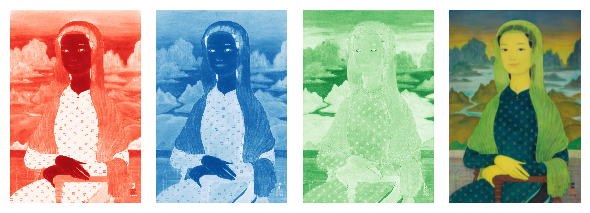

In [12]:
img_path = "../img/mona_lisa_maitrungthu.jpg"
img = [np.array(Image.open(img_path))]  # list so img[0] works

ind = 0  # use 0 since there's only one image

img1  = img[ind].T[0]
img2 = img[ind].T[1]
img3 = img[ind].T[2]


fig, axs = plt.subplots(1, 4, figsize=(6, 4))
for ax, (img_channel, cmap) in zip(axs.flat, [
    (img1,  'Reds'),
    (img2, 'Blues'),
    (img3, 'Greens'),
]):
    sns.heatmap(img_channel.T, cmap=cmap, alpha=1, ax=ax,
                linewidths=0,
                xticklabels=False, yticklabels=False, cbar=False,
                cbar_kws={'orientation': 'horizontal', 'location': 'bottom', 'pad': 0.05})
    ax.set_aspect('equal')
    sns.despine(ax=ax, top=True, right=True, left=True, bottom=True)

axs[3].imshow(img[ind])
axs[3].set_aspect('equal')
axs[3].set_axis_off()

plt.tight_layout()
plt.show()


In [13]:
# --- loading data
CACHE_DIR = Path('/Users/xqyn/Documents/learning/ai/mit6.S191_deeplearning/lab2/data')
#CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Get the training data: both images from CelebA and ImageNet
path_to_training_data = CACHE_DIR.joinpath("train_face.h5")

# # Create a simple check to avoid re-downloading
# if path_to_training_data.is_file():
#     print(f"Using cached training data from {path_to_training_data}")
# else:
#     print(f"Downloading training data to {path_to_training_data}")
#     url = "https://www.dropbox.com/s/hlz8atheyozp1yx/train_face.h5?dl=1"
#     torch.hub.download_url_to_file(url, path_to_training_data)

# Instantiate a TrainingDatasetLoader using the downloaded dataset
channels_last = False
loader = mdl.lab2.TrainingDatasetLoader(
    path_to_training_data, channels_last=channels_last
)

Opening /Users/xqyn/Documents/learning/ai/mit6.S191_deeplearning/lab2/data/train_face.h5
Loading data into memory...


In [14]:
(images, labels) = loader.get_batch(100)
B, C, H, W = images.shape
print(f'{B}-{C}-{H}-{W}')
#B, C, H, W = 100, 3, 64, 64

100-3-64-64


## Trainining data on model baseline CNN model

In [ ]:
params = dict(
    batch_size=32,
    learning_rate=5e-4,
    latent_dim=100,
    num_epochs=5,  
)


batch_size = params['batch_size']
num_epochs = params['num_epochs']
lr = params['learning_rate']

In [15]:
#sys.path.insert(0, str((Path.cwd() / '../').resolve()))
from irelium.dev import reload
from irelium.architecture import cnnConvNorm
from irelium.model.train import train
from irelium.utils import as_tensor
from irelium.loss.trace import LossHistory

In [ ]:
# --- setting the model
cnn_baseline = cnnConvNorm(
    n_outputs=1,
    H=H,
    W=W,
    in_channels=3,
    base_filter=12,
    stride=2,
    channel_schedule=[1, 2, 4, 6]
)
cnn_baseline = cnn_baseline.to(device)

# ---- loss function
loss_fn = nn.BCEWithLogitsLoss()
loss_history = LossHistory(smoothing_factor=0.99)


# --- optimizer
optimizer = torch.optim.Adam(
    cnn_baseline.parameters(),
    lr=lr,
)



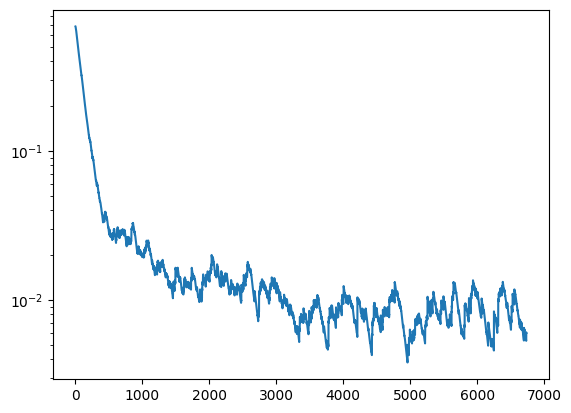

100%|██████████| 3434/3434 [00:47<00:00, 72.36it/s]


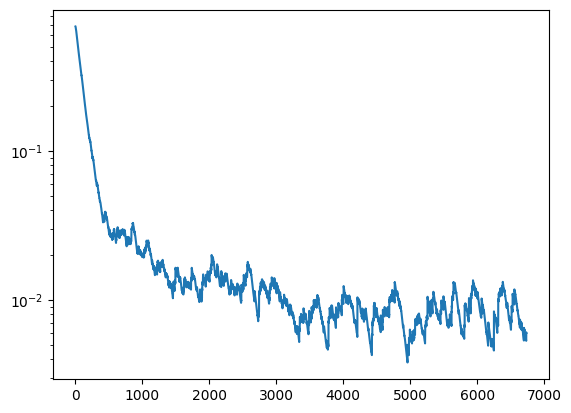

In [ ]:
loss_hist = mdl.util.LossHistory(smoothing_factor=0.99)  # to record loss evolution
plotter = mdl.util.PeriodicPlotter(sec=2, scale="semilogy")
step = 0
for epoch in range(num_epochs):
    for idx in tqdm(range(loader.get_train_size() // params["batch_size"])):
        x, y = loader.get_batch(batch_size)
        x = as_tensor(x, model=cnn_baseline)
        y = as_tensor(y, model=cnn_baseline)
        loss = train(
            x=x,
            y=y,
            model=cnn_baseline,
            step_fn=lambda x, y, model: loss_fn(model(x), y),
            optimizer=optimizer)
        loss_value = loss.detach().cpu().numpy()
        loss_history.append(loss_value)
        loss_hist.append(loss_value)
        plotter.plot(loss_hist.get())
        step += 1

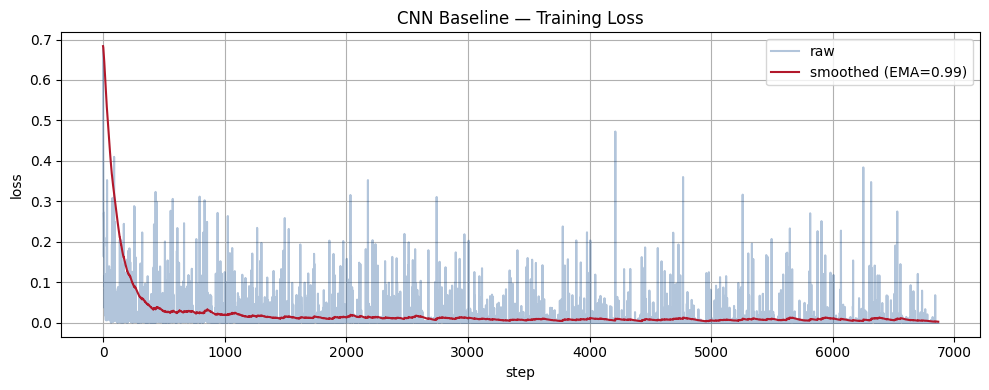

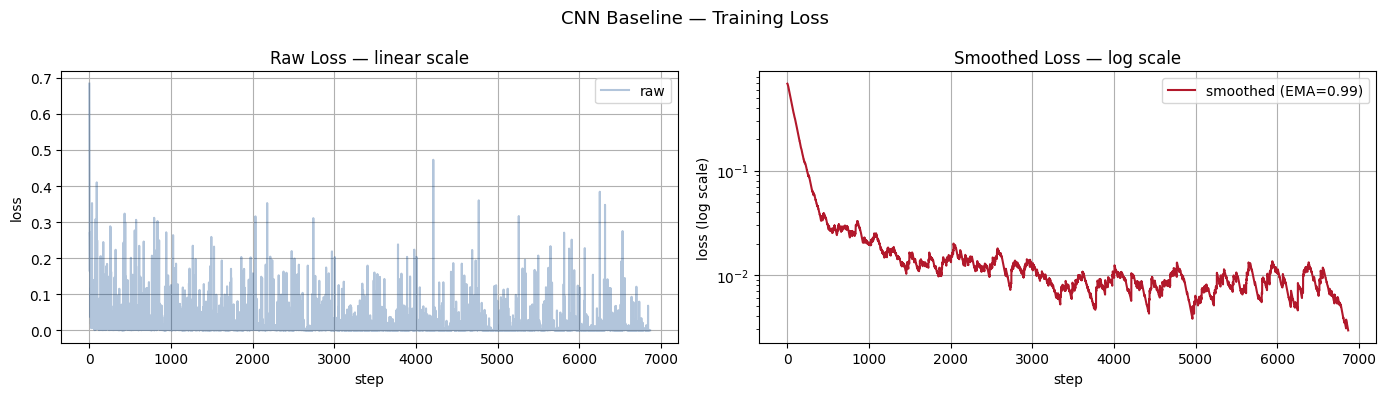

In [14]:
# raw + smoothed overlay
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(loss_history.raw,    color='#003f88', alpha=0.3, label='raw')
ax.plot(loss_history.smooth, color='#B2182B',            label='smoothed (EMA=0.99)')
ax.set_xlabel('step')
ax.set_ylabel('loss')
ax.set_title('CNN Baseline — Training Loss')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.savefig(f'{fig_dir}/cnn_base_training.png', dpi=320)
plt.show()
plt.close()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(loss_history.raw,    color='#003f88', alpha=0.3, label='raw')
ax1.set_xlabel('step')
ax1.set_ylabel('loss')
ax1.set_title('Raw Loss — linear scale')
ax1.grid(True)
ax1.legend()

ax2.plot(loss_history.smooth, color='#B2182B', label='smoothed (EMA=0.99)')
ax2.set_yscale('log')
ax2.set_xlabel('step')
ax2.set_ylabel('loss (log scale)')
ax2.set_title('Smoothed Loss — log scale')
ax2.grid(True)
ax2.legend()

plt.suptitle('CNN Baseline — Training Loss', fontsize=13)
plt.tight_layout()
plt.savefig(f'{fig_dir}/cnn_base_training_ema.png', dpi=150)
plt.show()
plt.close()

In [15]:
# Full diagnostic of a loss tensor
def inspect_tensor(t: torch.Tensor) -> None:
    print(f"value        : {t.item():.6f}")
    print(f"shape        : {t.shape}")
    print(f"dtype        : {t.dtype}")
    print(f"device       : {t.device}")
    print(f"requires_grad: {t.requires_grad}")
    print(f"grad_fn      : {t.grad_fn}")
    print(f"grad_fn name : {t.grad_fn.__class__.__name__ if t.grad_fn else None}")
    print(f"is_leaf      : {t.is_leaf}")
    print(f"is_scalar    : {t.ndim == 0}")
    print(f"memory (MB)  : {t.element_size() * t.nelement() / 1e6:.4f}")

inspect_tensor(loss)

value        : 0.000020
shape        : torch.Size([])
dtype        : torch.float32
device       : mps:0
requires_grad: True
grad_fn      : <BinaryCrossEntropyWithLogitsBackward0 object at 0x1387eeaa0>
grad_fn name : BinaryCrossEntropyWithLogitsBackward0
is_leaf      : False
is_scalar    : True
memory (MB)  : 0.0000


In [20]:
from irelium.model.train import evaluation

images, labels = loader.get_batch(5000)
images = as_tensor(images, model=cnn_baseline)
labels = as_tensor(labels, model=cnn_baseline)
acc = evaluation(
        x=images,
        y=labels,
        model=cnn_baseline,
        pred_fn=lambda logits: (torch.sigmoid(logits) > 0.5).float(),
        metric_fn=lambda y_pred, y: (y_pred == y).float().mean()
)

print(" CNN baseline accuracy on (potentially biased) training set: {:.4f}".format(
        acc.item()))

 CNN baseline accuracy on (potentially biased) training set: 0.9978


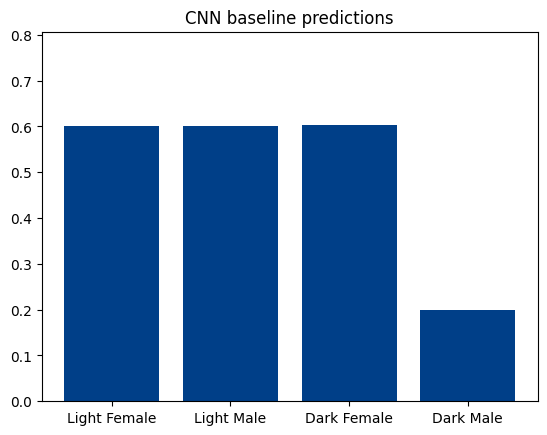

In [21]:
test_faces = mdl.lab2.get_test_faces(channels_last=channels_last)
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]

cnnbase_model_probs_list = []  # store each demographic's probabilities

with torch.inference_mode():
    for x in test_faces:
        x = torch.from_numpy(np.array(x, dtype=np.float32)).to(device)
        logits = cnn_baseline(x)  # [B, 1]
        probs = torch.sigmoid(logits)  # [B, 1]
        probs = torch.squeeze(probs, dim=-1)  # shape [B]
        cnnbase_model_probs_list.append(probs.cpu().numpy())

cnnbase_model_probs = np.stack(cnnbase_model_probs_list, axis=0)


# Plot the prediction accuracies per demographic
xx = range(len(keys))
yy = cnnbase_model_probs.mean(axis=1)  # shape [D]
plt.bar(xx, yy, color='#003f88')
plt.xticks(xx, keys)
plt.ylim(max(0, yy.min() - np.ptp(yy) / 2.0), yy.max() + np.ptp(yy) / 2.0)
plt.title("CNN baseline predictions")
plt.savefig(f'{fig_dir}cnn_baselie_prdiction.png')

In [22]:
make_dot(loss, params=dict(cnn_baseline.named_parameters())).render(f'{fig_dir}/loss_graph', format="png")

'../img/dbvae/loss_graph.png'

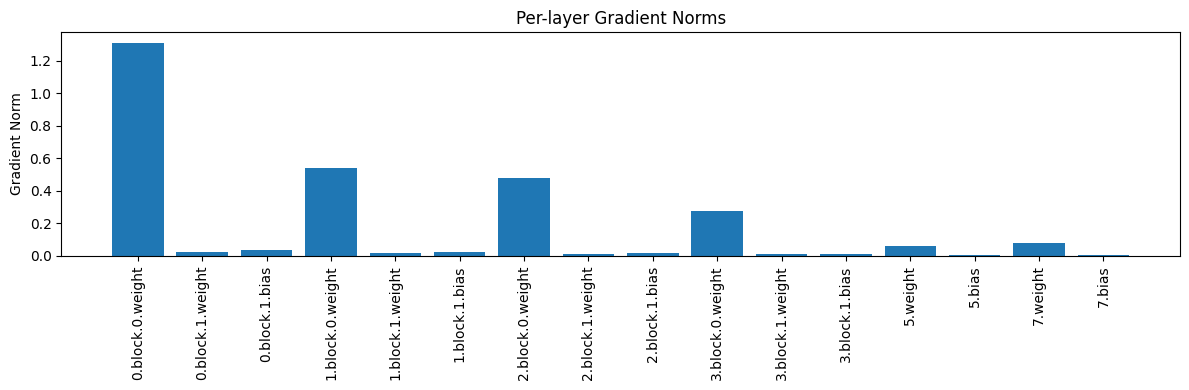

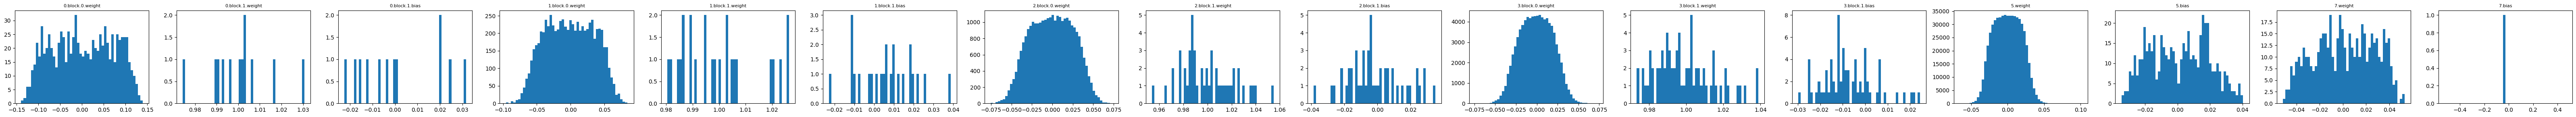

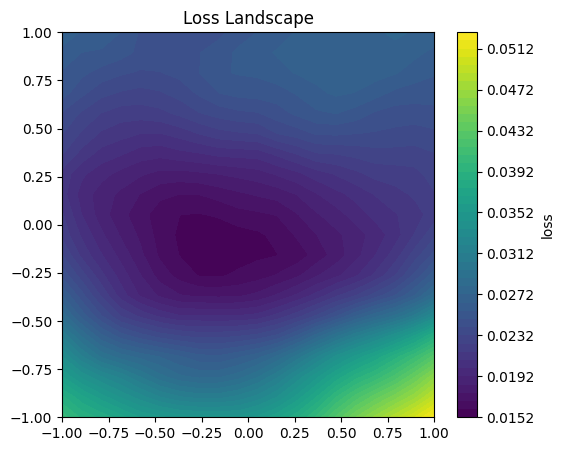

In [ ]:
# call after loss.backward()
plot_grad_norms(cnn_baseline)
plot_weight_distributions(cnn_baseline)
plot_loss_landscape(cnn_baseline, loss_fn, x, y)

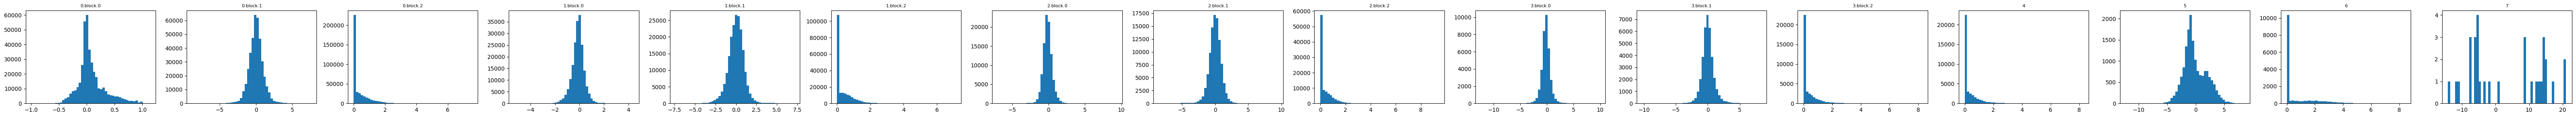

In [ ]:
plot_activations(cnn_baseline, x)

# Debiasing variational autoencoder (DB-VAE)

In [25]:
from irelium.loss.dbvae import dbvae_step_fn
from irelium.architecture.dbvae import DB_VAE, get_train_sample_probability
from irelium.dev import reload
from irelium.model.train import train
from irelium.architecture.vae import _Reshape
reload(dbvae_step_fn)
reload(get_train_sample_probability)

<function irelium.architecture.dbvae.get_train_sample_probability(images: numpy.ndarray | torch.Tensor, model: irelium.architecture.dbvae.DB_VAE, bins: int = 10, batch_size: int = 64, smoothing_fac: float = 0.001) -> <built-in function array>>

In [17]:
params = dict(
    batch_size=32,
    learning_rate=5e-4,
    latent_dim=100,
    num_epochs=5,  
)

batch_size = params['batch_size']
num_epochs = params['num_epochs']
lr = params['learning_rate']
latent_dim = params['latent_dim']

In [3]:
B, C, H, W = 100, 3, 64, 64

In [34]:
# --- setting the model
dbvae_fac = DB_VAE(
    H=H,
    W=W,
    in_channels=3,
    latent_dim=latent_dim,
    base_filter=12
).to(device)

# ---- loss function
#loss_fn = dbvae_step_fn()

loss_history = LossHistory(smoothing_factor=0.99)


# --- optimizer
optimizer = torch.optim.Adam(
    dbvae_fac.parameters(),
    lr=lr,
)

In [35]:
# get training faces from data loader
all_faces = loader.get_all_train_faces()

Starting epoch 5/5


  0%|          | 0/3434 [00:00<?, ?it/s]

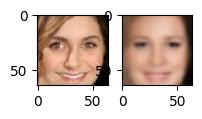

 15%|█▍        | 498/3434 [00:08<00:50, 57.69it/s]

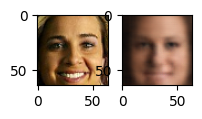

 29%|██▉       | 997/3434 [00:16<00:37, 64.14it/s]

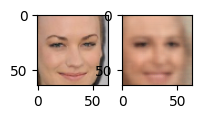

 44%|████▎     | 1497/3434 [00:24<00:35, 54.71it/s]

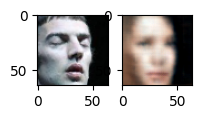

 58%|█████▊    | 1998/3434 [00:32<00:22, 63.48it/s]

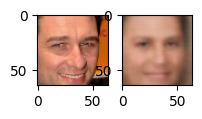

 73%|███████▎  | 2497/3434 [00:41<00:15, 62.25it/s]

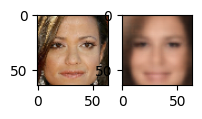

 87%|████████▋ | 2998/3434 [00:49<00:06, 63.42it/s]

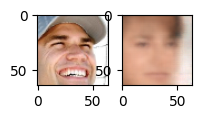

100%|██████████| 3434/3434 [00:56<00:00, 60.79it/s]


In [36]:
loss_hist = mdl.util.LossHistory(smoothing_factor=0.99)  # to record loss evolution
plotter = mdl.util.PeriodicPlotter(sec=2, scale="semilogy")
step = 0
for epoch in range(num_epochs):
    IPython.display.clear_output(wait=True)
    print("Starting epoch {}/{}".format(epoch + 1, params["num_epochs"]))
    
    #  recompute data sampling proabilities
    p_faces = get_train_sample_probability(all_faces, dbvae_fac)
    
    # get a batch of training data and compute the training step
    for idx in tqdm(range(loader.get_train_size() // batch_size)):
        # load a batch of data
        (x, y) = loader.get_batch(batch_size, p_pos=p_faces)
        x, y = loader.get_batch(batch_size)
        x = as_tensor(x, model=dbvae_fac)
        y = as_tensor(y, model=dbvae_fac)
        loss = train(
            x=x,
            y=y,
            model=dbvae_fac,
            step_fn=lambda x, y, model: dbvae_step_fn(x, y, model),
            optimizer=optimizer)
        loss_value = loss.detach().cpu().numpy()
        loss_history.append(loss_value)
        loss_hist.append(loss_value)
        #plotter.plot(loss_hist.get())
        if idx % 500 == 0:
            mdl.util.plot_sample(x, y, dbvae_fac, backend="pt")
        step += 1

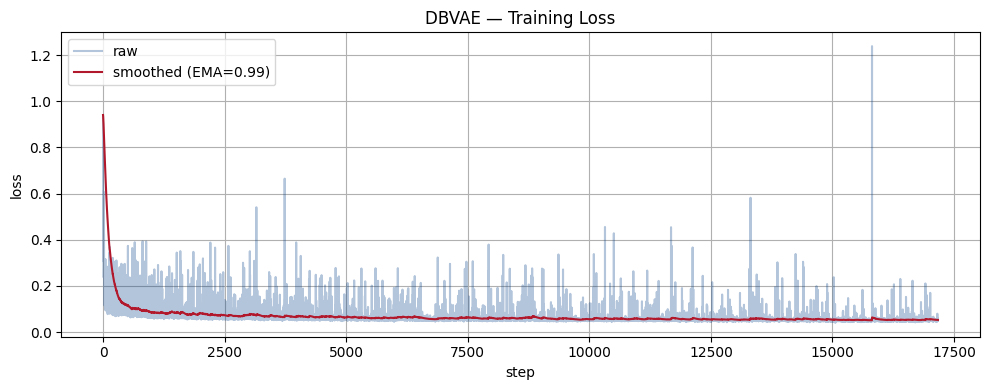

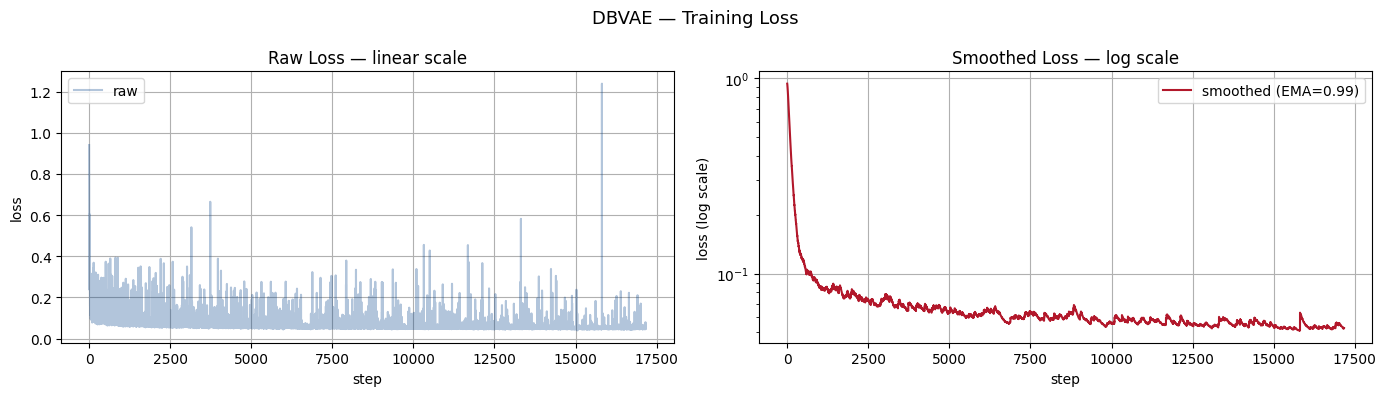

In [39]:
# raw + smoothed overlay
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(loss_history.raw,    color='#003f88', alpha=0.3, label='raw')
ax.plot(loss_history.smooth, color='#B2182B',            label='smoothed (EMA=0.99)')
ax.set_xlabel('step')
ax.set_ylabel('loss')
ax.set_title('DBVAE — Training Loss')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.savefig(f'{fig_dir}/dbvae_base_training.png', dpi=320)
plt.show()
plt.close()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(loss_history.raw,    color='#003f88', alpha=0.3, label='raw')
ax1.set_xlabel('step')
ax1.set_ylabel('loss')
ax1.set_title('Raw Loss — linear scale')
ax1.grid(True)
ax1.legend()

ax2.plot(loss_history.smooth, color='#B2182B', label='smoothed (EMA=0.99)')
ax2.set_yscale('log')
ax2.set_xlabel('step')
ax2.set_ylabel('loss (log scale)')
ax2.set_title('Smoothed Loss — log scale')
ax2.grid(True)
ax2.legend()

plt.suptitle('DBVAE — Training Loss', fontsize=13)
plt.tight_layout()
plt.savefig(f'{fig_dir}/dbvae_training_ema.png', dpi=150)
plt.show()
plt.close()